In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
dataset_dir = './datasets/processed_data'

In [3]:
import gc
import os
import tensorflow as tf
from tensorflow.keras import backend as K

print("Configuring GPU memory growth and clearing previous Keras sessions...")
K.clear_session()
gc.collect()

# Configure TensorFlow to only allocate memory as needed on the GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU growth enabled and configured: {gpus}")
    except RuntimeError as e:
        print(f"GPU configuration warning (might be already initialized): {e}")
else:
    print("No GPU detected, running on CPU fallback.")

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# 1. Load the real dataset windows
train_path = os.path.join(dataset_dir, 'train_windows.npz')
val_path = os.path.join(dataset_dir, 'val_windows.npz')
test_path = os.path.join(dataset_dir, 'test_windows.npz')

print("Loading datasets...")
train_data = np.load(train_path)
val_data = np.load(val_path)
test_data = np.load(test_path)

Loading datasets...


### 1. Standalone LSTM Model
This cell defines, trains, and evaluates a standalone LSTM-based Encoder-Decoder Model.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Reshape
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure dataset is loaded if kernel was restarted
if 'X_train' not in globals():
    print("Loading datasets...")
    X_train = np.load(os.path.join(dataset_dir, 'train_windows.npz'))['X']
    y_train = np.load(os.path.join(dataset_dir, 'train_windows.npz'))['y']
    X_val = np.load(os.path.join(dataset_dir, 'val_windows.npz'))['X']
    y_val = np.load(os.path.join(dataset_dir, 'val_windows.npz'))['y']
    X_test = np.load(os.path.join(dataset_dir, 'test_windows.npz'))['X']
    y_test = np.load(os.path.join(dataset_dir, 'test_windows.npz'))['y']

time_steps = X_train.shape[1]
features = X_train.shape[2]
out_steps = y_train.shape[1]

# Force CPU execution to bypass CUDA_ERROR_INVALID_HANDLE
with tf.device('/CPU:0'):
    print("Building Multi-Step Vanilla LSTM model on CPU...")
    model = Sequential([
        Input(shape=(time_steps, features)),
        LSTM(50, activation='relu'),
        Dense(out_steps),
        Reshape((out_steps, 1))
    ])

    model.compile(optimizer='adam', loss='mse')
    model.summary()

    print("\nTraining vanilla LSTM model...")
    history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_val, y_val), verbose=1)

    print("\nEvaluating on Test Set...")
    predictions = model.predict(X_test)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

print("\n--- Performance across forecasting horizons (t+1 to t+12) ---")
for step in range(12):
    y_true_step = y_test[:, step, 0]
    y_pred_step = predictions[:, step, 0]

    rmse = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mae = mean_absolute_error(y_true_step, y_pred_step)
    mape = mean_absolute_percentage_error(y_true_step, y_pred_step)

    print(f"Horizon t+{step+1:02d}: RMSE = {rmse:.4f} | MAE = {mae:.4f} | MAPE = {mape:.2f}%")

Building Multi-Step Vanilla LSTM model on CPU...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 24, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,424 (79.78 KB)

 Trainable params: 20,424 (79.78 KB)

 Non-trainable params: 0 (0.00 B)


Training vanilla LSTM model...
Epoch 1/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 60s 25ms/step - loss: 0.0131 - val_loss: 1.6954e-04
Epoch 2/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 81s 25ms/step - loss: 1.3090e-04 - val_loss: 1.1665e-04
Epoch 3/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - loss: 1.0820e-04 - val_loss: 9.8623e-05
Epoch 4/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - loss: 1.0198e-04 - val_loss: 1.4517e-04
Epoch 5/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - loss: 9.7922e-05 - val_loss: 8.9943e-05

Evaluating on Test Set...
514/514 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

--- Performance across forecasting horizons (t+1 to t+12) ---
Horizon t+01: RMSE = 0.0061 | MAE = 0.0045 | MAPE = 0.44%
Horizon t+02: RMSE = 0.0082 | MAE = 0.0058 | MAPE = 0.57%
Horizon t+03: RMSE = 0.0083 | MAE = 0.0054 | MAPE = 0.54%
Horizon t+04: RMSE = 0.0099 | MAE = 0.0066 | MAPE = 0.65%
Horizon t+05: RMSE = 0.0106 | MAE = 0.0070 | MAPE = 0.69%
Horizon t+06: RMSE = 0.0112 | MAE = 0.0072 | MAPE = 0.71%
Horizon 

### 2. Standalone GRU Model
This cell defines, trains, and evaluates a standalone Multi-Step GRU Model on the dataset.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input, Reshape
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure dataset is loaded if kernel was restarted

if 'X_train' not in globals():
    print("Loading datasets...")
    X_train = np.load(os.path.join(dataset_dir, 'train_windows.npz'))['X']
    y_train = np.load(os.path.join(dataset_dir, 'train_windows.npz'))['y']
    X_val = np.load(os.path.join(dataset_dir, 'val_windows.npz'))['X']
    y_val = np.load(os.path.join(dataset_dir, 'val_windows.npz'))['y']
    X_test = np.load(os.path.join(dataset_dir, 'test_windows.npz'))['X']
    y_test = np.load(os.path.join(dataset_dir, 'test_windows.npz'))['y']

time_steps = X_train.shape[1]
features = X_train.shape[2]
out_steps = y_train.shape[1]

# Force CPU execution to bypass CUDA_ERROR_INVALID_HANDLE
with tf.device('/CPU:0'):
    print("Building Standalone GRU Model on CPU...")
    gru_model = Sequential([
        Input(shape=(time_steps, features)),
        GRU(64, activation='tanh', return_sequences=False),
        Dense(out_steps),
        Reshape((out_steps, 1))
    ])

    gru_model.compile(optimizer='adam', loss='mse')
    gru_model.summary()

    print("\nTraining Standalone GRU model...")
    history_gru = gru_model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=128,
        validation_data=(X_val, y_val),
        verbose=1
    )

    print("\nEvaluating Standalone GRU on Test Set...")
    preds_gru = gru_model.predict(X_test)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

gru_metrics = {'rmse': [], 'mae': [], 'mape': []}
print("\n--- Standalone GRU Performance across horizons (t+1 to t+12) ---")
for step in range(12):
    y_true_step = y_test[:, step, 0]
    y_pred_step = preds_gru[:, step, 0]

    rmse = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mae = mean_absolute_error(y_true_step, y_pred_step)
    mape = mean_absolute_percentage_error(y_true_step, y_pred_step)

    gru_metrics['rmse'].append(rmse)
    gru_metrics['mae'].append(mae)
    gru_metrics['mape'].append(mape)

    print(f"Horizon t+{step+1:02d}: RMSE = {rmse:.4f} | MAE = {mae:.4f} | MAPE = {mape:.2f}%")

Loading datasets...
Building Standalone GRU Model on CPU...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        21,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,872 (89.34 KB)

 Trainable params: 22,872 (89.34 KB)

 Non-trainable params: 0 (0.00 B)


Training Standalone GRU model...
Epoch 1/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 123s 52ms/step - loss: 0.0182 - val_loss: 2.7419e-04
Epoch 2/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 114s 49ms/step - loss: 1.6551e-04 - val_loss: 1.2554e-04
Epoch 3/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 154s 54ms/step - loss: 1.1991e-04 - val_loss: 1.0165e-04
Epoch 4/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 123s 53ms/step - loss: 1.0556e-04 - val_loss: 9.5918e-05
Epoch 5/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 112s 48ms/step - loss: 9.4280e-05 - val_loss: 8.5947e-05

Evaluating Standalone GRU on Test Set...
514/514 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

--- Standalone GRU Performance across horizons (t+1 to t+12) ---
Horizon t+01: RMSE = 0.0087 | MAE = 0.0070 | MAPE = 0.69%
Horizon t+02: RMSE = 0.0079 | MAE = 0.0055 | MAPE = 0.54%
Horizon t+03: RMSE = 0.0107 | MAE = 0.0081 | MAPE = 0.79%
Horizon t+04: RMSE = 0.0106 | MAE = 0.0075 | MAPE = 0.74%
Horizon t+05: RMSE = 0.0106 | MAE = 0.0071 | MAPE = 0.70%
Horizon t+06: RMSE = 0.0111 | MAE = 0.007

### 3. Standalone LSTM Encoder-Decoder Model
This cell defines, trains, and evaluates a standalone LSTM-based Encoder-Decoder Model.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure dataset is loaded if kernel was restarted
if 'X_train' not in globals():
    print("Loading datasets...")
    X_train = np.load(os.path.join(dataset_dir, 'train_windows.npz'))['X']
    y_train = np.load(os.path.join(dataset_dir, 'train_windows.npz'))['y']
    X_val = np.load(os.path.join(dataset_dir, 'val_windows.npz'))['X']
    y_val = np.load(os.path.join(dataset_dir, 'val_windows.npz'))['y']
    X_test = np.load(os.path.join(dataset_dir, 'test_windows.npz'))['X']
    y_test = np.load(os.path.join(dataset_dir, 'test_windows.npz'))['y']

time_steps = X_train.shape[1]
features = X_train.shape[2]
out_steps = y_train.shape[1]

# Force CPU execution to bypass CUDA_ERROR_INVALID_HANDLE
with tf.device('/CPU:0'):
    print("Building Standalone LSTM Encoder-Decoder Model on CPU...")
    latent_dim = 64

    encoder_inputs = Input(shape=(time_steps, features))
    encoder_lstm = LSTM(latent_dim, return_state=True)
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
    encoder_states = [state_h, state_c]

    decoder_input_sequences = RepeatVector(out_steps)(state_h)
    decoder_lstm = LSTM(latent_dim, return_sequences=True)
    decoder_outputs = decoder_lstm(decoder_input_sequences, initial_state=encoder_states)

    decoder_dense = TimeDistributed(Dense(1))
    model_outputs = decoder_dense(decoder_outputs)

    lstm_enc_dec_model = Model(encoder_inputs, model_outputs)
    lstm_enc_dec_model.compile(optimizer='adam', loss='mse')
    lstm_enc_dec_model.summary()

    print("\nTraining Standalone LSTM Encoder-Decoder model...")
    history_lstm_enc_dec = lstm_enc_dec_model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=128,
        validation_data=(X_val, y_val),
        verbose=1
    )

    print("\nEvaluating Standalone LSTM Encoder-Decoder on Test Set...")
    preds_lstm_enc_dec = lstm_enc_dec_model.predict(X_test)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

lstm_ed_metrics = {'rmse': [], 'mae': [], 'mape': []}
print("\n LSTM Encoder-Decoder Performance across horizons (t+1 to t+12) ")
for step in range(12):
    y_true_step = y_test[:, step, 0]
    y_pred_step = preds_lstm_enc_dec[:, step, 0]

    rmse = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mae = mean_absolute_error(y_true_step, y_pred_step)
    mape = mean_absolute_percentage_error(y_true_step, y_pred_step)

    lstm_ed_metrics['rmse'].append(rmse)
    lstm_ed_metrics['mae'].append(mae)
    lstm_ed_metrics['mape'].append(mape)

    print(f"Horizon t+{step+1:02d}: RMSE = {rmse:.4f} | MAE = {mae:.4f} | MAPE = {mape:.2f}%")

Building Standalone LSTM Encoder-Decoder Model on CPU...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 45)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     28,160 │ input_layer_1[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 64)    │          0 │ lstm[0][1]        │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     33,024 │ repeat_vector[0]… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 1)     │         65 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,249 (239.25 KB)

 Trainable params: 61,249 (239.25 KB)

 Non-trainable params: 0 (0.00 B)


Training Standalone LSTM Encoder-Decoder model...
Epoch 1/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 239s 101ms/step - loss: 0.0050 - val_loss: 9.6339e-05
Epoch 2/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 250s 107ms/step - loss: 9.8445e-05 - val_loss: 7.8616e-05
Epoch 3/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 235s 101ms/step - loss: 8.9651e-05 - val_loss: 1.0739e-04
Epoch 4/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 236s 102ms/step - loss: 8.2275e-05 - val_loss: 8.2485e-05
Epoch 5/5
2327/2327 ━━━━━━━━━━━━━━━━━━━━ 235s 101ms/step - loss: 9.2810e-05 - val_loss: 8.5534e-05

Evaluating Standalone LSTM Encoder-Decoder on Test Set...
514/514 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step

 LSTM Encoder-Decoder Performance across horizons (t+1 to t+12) 
Horizon t+01: RMSE = 0.0132 | MAE = 0.0101 | MAPE = 0.99%
Horizon t+02: RMSE = 0.0100 | MAE = 0.0072 | MAPE = 0.71%
Horizon t+03: RMSE = 0.0091 | MAE = 0.0059 | MAPE = 0.58%
Horizon t+04: RMSE = 0.0098 | MAE = 0.0062 | MAPE = 0.62%
Horizon t+05: RMSE = 0.0104 | MAE = 0.0066 | MAPE = 0.66%
H

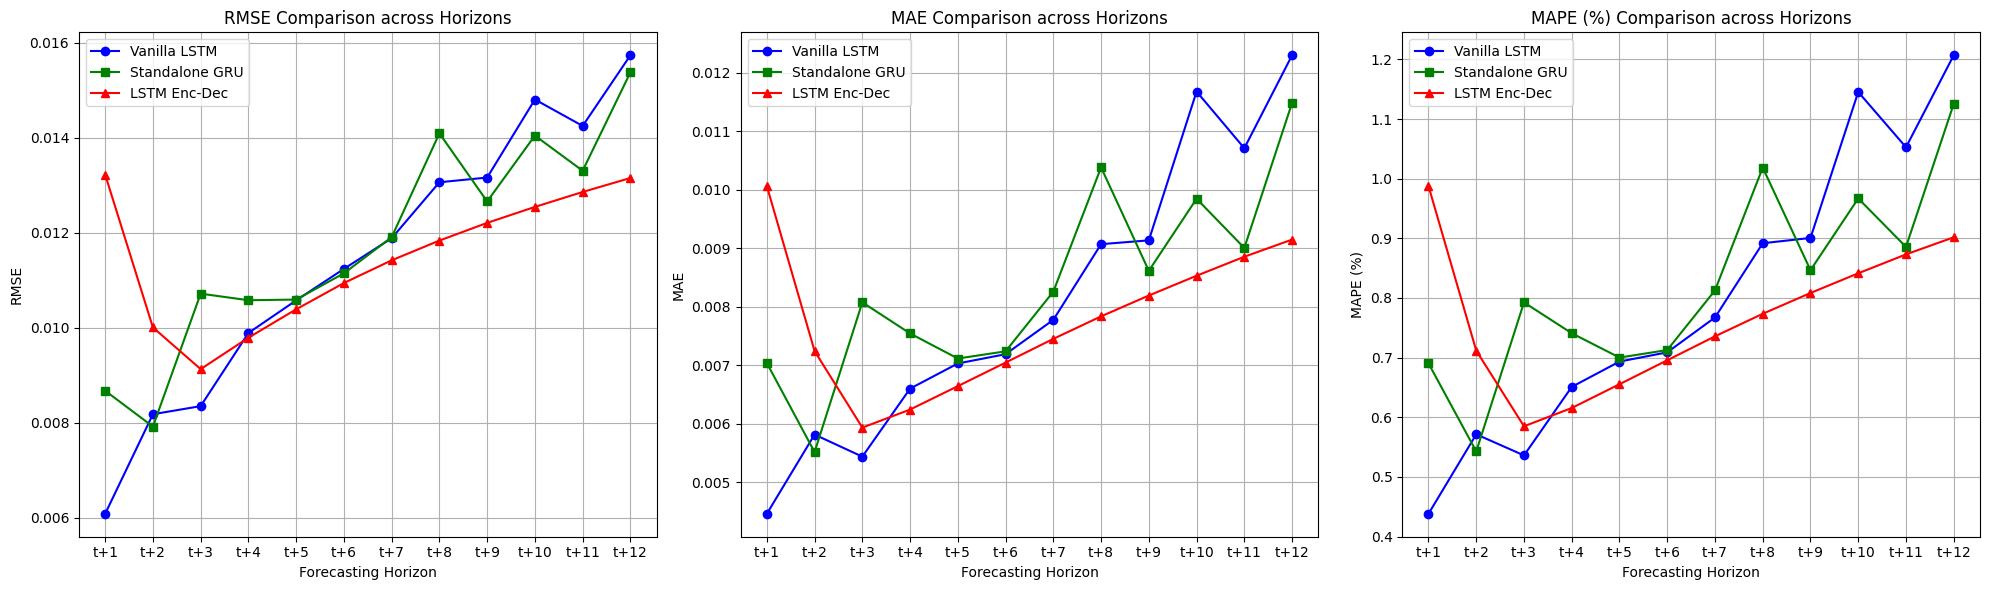

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure dataset is loaded if kernel was restarted
dataset_dir = '/content/drive/MyDrive/ML_Dataset/processed_data'
if 'y_test' not in globals():
    y_test = np.load(os.path.join(dataset_dir, 'test_windows.npz'))['y']

horizons = [f"t+{i}" for i in range(1, 13)]

def get_metrics_for_pred(predictions):
    rmse_list, mae_list, mape_list = [], [], []
    for step in range(12):
        y_true_step = y_test[:, step, 0]
        y_pred_step = predictions[:, step, 0]
        rmse_list.append(np.sqrt(mean_squared_error(y_true_step, y_pred_step)))
        mae_list.append(mean_absolute_error(y_true_step, y_pred_step))
        mape_list.append(np.mean(np.abs((y_true_step - y_pred_step) / (y_true_step + 1e-8))) * 100)
    return rmse_list, mae_list, mape_list

try:
    # Recalculate metrics for all models
    vanilla_rmse, vanilla_mae, vanilla_mape = get_metrics_for_pred(predictions)
    gru_rmse, gru_mae, gru_mape = get_metrics_for_pred(preds_gru)
    lstm_ed_rmse, lstm_ed_mae, lstm_ed_mape = get_metrics_for_pred(preds_lstm_enc_dec)

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # 1. RMSE Plot
    axes[0].plot(horizons, vanilla_rmse, marker='o', label='Vanilla LSTM', color='blue')
    axes[0].plot(horizons, gru_rmse, marker='s', label='Standalone GRU', color='green')
    axes[0].plot(horizons, lstm_ed_rmse, marker='^', label='LSTM Enc-Dec', color='red')
    axes[0].set_title('RMSE Comparison across Horizons')
    axes[0].set_xlabel('Forecasting Horizon')
    axes[0].set_ylabel('RMSE')
    axes[0].grid(True)
    axes[0].legend()

    # 2. MAE Plot
    axes[1].plot(horizons, vanilla_mae, marker='o', label='Vanilla LSTM', color='blue')
    axes[1].plot(horizons, gru_mae, marker='s', label='Standalone GRU', color='green')
    axes[1].plot(horizons, lstm_ed_mae, marker='^', label='LSTM Enc-Dec', color='red')
    axes[1].set_title('MAE Comparison across Horizons')
    axes[1].set_xlabel('Forecasting Horizon')
    axes[1].set_ylabel('MAE')
    axes[1].grid(True)
    axes[1].legend()

    # 3. MAPE Plot
    axes[2].plot(horizons, vanilla_mape, marker='o', label='Vanilla LSTM', color='blue')
    axes[2].plot(horizons, gru_mape, marker='s', label='Standalone GRU', color='green')
    axes[2].plot(horizons, lstm_ed_mape, marker='^', label='LSTM Enc-Dec', color='red')
    axes[2].set_title('MAPE (%) Comparison across Horizons')
    axes[2].set_xlabel('Forecasting Horizon')
    axes[2].set_ylabel('MAPE (%)')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
except NameError as e:
    print(f"Could not plot comparison: {e}. Ensure all three model training cells have finished execution.")

### Metric Analysis & Observations:

Short-Term Horizons ($t+1$ to $t+3$):
* Vanilla LSTM outperforms the other models significantly at $t+1$ with an RMSE around 0.0061 and MAPE around 0.44%.
* LSTM Encoder-Decoder starts with higher errors at $t+1$$t+1$ (RMSE 0.0132), which is a typical characteristic of sequence-to-sequence models since the decoder initially reconstructs sequences based on compressed context vectors.

Longer-Term Horizons ($t+4$ to $t+12$):
* LSTM Encoder-Decoder demonstrates its architectural strength for long-range dependencies. While other architectures degrade more rapidly as the horizon stretches, the Encoder-Decoder's error increases much more gradually. By $t+12$, it achieves the best performance with an RMSE of 0.0132, MAE of 0.0092, and MAPE of 0.90%.
* Standalone GRU and Vanilla LSTM exhibit more volatile performance degradation as the horizon increases, peaking at $t+12$ with the highest errors (MAPE of 1.13% and 1.21% respectively).
